<a href="https://colab.research.google.com/github/Dhanush7-tech/Deep-Learning-LAB/blob/main/Lab-3/DeepLearning_Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN for Image Classification on CIFAR-10 (TensorFlow / Keras)

**Aim:** Design, implement, train, and evaluate a Convolutional Neural Network for
multi-class image classification on the CIFAR-10 dataset, and study the effect of
key CNN hyperparameters (kernel size, stride, padding, number of filters,
optimizer, batch size, epochs) and pooling strategies on model performance.

**Sections**
1. Setup & imports
2. Load CIFAR-10, explore class distribution and sample images
3. Build baseline CNN architecture
4. Analyze trainable parameters of convolutional layers
5. Train the baseline model
6. Training/validation accuracy & loss curves
7. Evaluation: accuracy, precision, recall, F1-score, confusion matrix, classification report
8. Visualize intermediate feature maps
9. Hyperparameter study: kernel size, filters, stride/padding
10. Pooling strategy comparison (Max vs Average vs no pooling)
11. Optimizer & batch size comparison
12. Conclusion


## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score,
                              recall_score, f1_score)
import seaborn as sns
import time

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: []


## 2. Load CIFAR-10 Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Train images:", x_train.shape, "Train labels:", y_train.shape)
print("Test images :", x_test.shape,  "Test labels :", y_test.shape)

# Normalize pixel values to [0, 1]
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm  = x_test.astype("float32") / 255.0

# Flatten label arrays
y_train_flat = y_train.flatten()
y_test_flat  = y_test.flatten()

# One-hot encode for training
y_train_cat = keras.utils.to_categorical(y_train_flat, 10)
y_test_cat  = keras.utils.to_categorical(y_test_flat, 10)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 520s 3us/step
Train images: (50000, 32, 32, 3) Train labels: (50000, 1)
Test images : (10000, 32, 32, 3) Test labels : (10000, 1)


### 2.1 Class Distribution

/tmp/ipykernel_1456/157204532.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(class_names, rotation=45, ha='right')
/tmp/ipykernel_1456/157204532.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(class_names, rotation=45, ha='right')


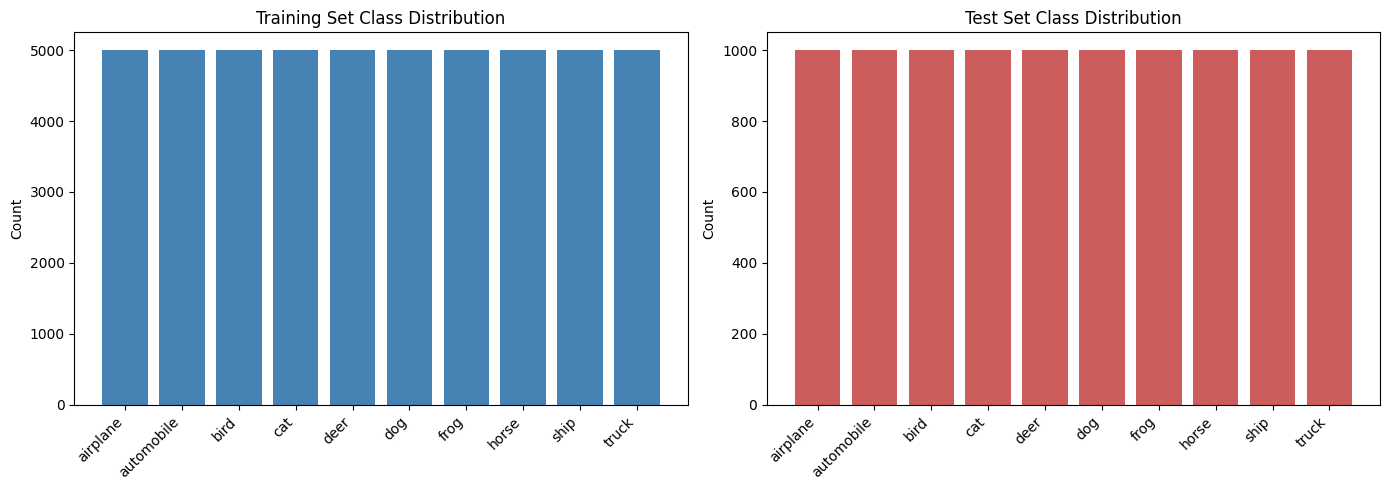

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_counts = np.bincount(y_train_flat)
test_counts  = np.bincount(y_test_flat)

axes[0].bar(class_names, train_counts, color='steelblue')
axes[0].set_title("Training Set Class Distribution")
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].set_ylabel("Count")

axes[1].bar(class_names, test_counts, color='indianred')
axes[1].set_title("Test Set Class Distribution")
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


### 2.2 Sample Images

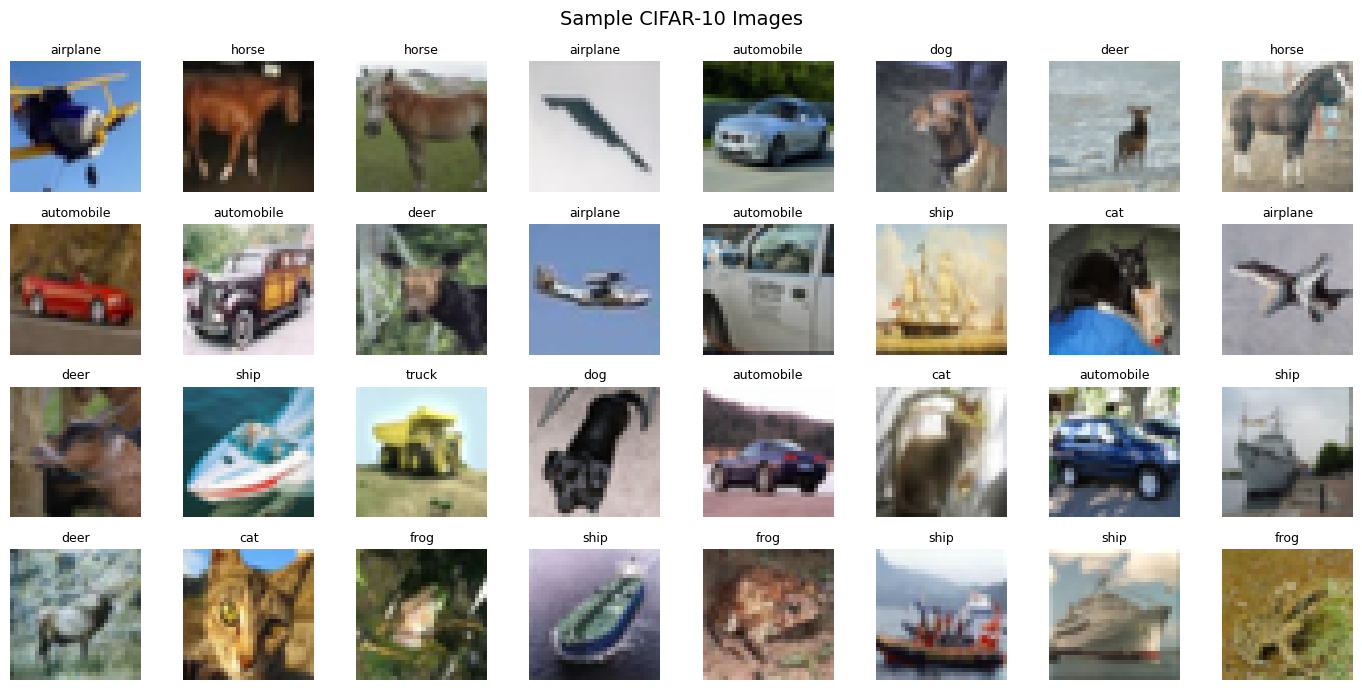

In [4]:
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
rng = np.random.default_rng(42)
idxs = rng.choice(len(x_train), 32, replace=False)

for ax, idx in zip(axes.flat, idxs):
    ax.imshow(x_train[idx])
    ax.set_title(class_names[y_train_flat[idx]], fontsize=9)
    ax.axis("off")

plt.suptitle("Sample CIFAR-10 Images", fontsize=14)
plt.tight_layout()
plt.show()


## 3. Build the Baseline CNN Architecture

Architecture:
`Conv(32,3x3) -> ReLU -> MaxPool(2x2) -> Conv(64,3x3) -> ReLU -> MaxPool(2x2)
-> Conv(64,3x3) -> ReLU -> Flatten -> Dense(64) -> Dense(10, softmax)`


In [8]:
def build_baseline_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, kernel_size=(3, 3), strides=1, padding='same', activation='relu', name='conv1'),
        layers.MaxPooling2D(pool_size=(2, 2), name='pool1'),

        layers.Conv2D(64, kernel_size=(3, 3), strides=1, padding='same', activation='relu', name='conv2'),
        layers.MaxPooling2D(pool_size=(2, 2), name='pool2'),

        layers.Conv2D(64, kernel_size=(3, 3), strides=1, padding='same', activation='relu', name='conv3'),

        layers.Flatten(name='flatten'),
        layers.Dense(64, activation='relu', name='dense1'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,178 (1.22 MB)

 Trainable params: 319,178 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Trainable Parameters of Convolutional Layers

For a Conv2D layer: `params = (kernel_h * kernel_w * in_channels + 1) * num_filters`
(the `+1` accounts for the bias term per filter).


In [11]:
print(f"{'Layer':<12}{'Type':<15}{'Output Shape':<20}{'Params':>10}")
print("-" * 60)
total_conv_params = 0
for layer in baseline_model.layers:
    params = layer.count_params()
    if 'conv' in layer.name:
        total_conv_params += params
    # Fix: Directly convert layer.output.shape to string, as it can be a tuple
    print(f"{layer.name:<12}{layer.__class__.__name__:<15}{str(layer.output.shape):<20}{params:>10,}")

print("-" * 60)
print(f"Total trainable parameters in Conv2D layers: {total_conv_params:,}")
print(f"Total trainable parameters in the model:     {baseline_model.count_params():,}")

# Manual verification for conv1: (3*3*3 + 1) * 32
manual_conv1 = (3 * 3 * 3 + 1) * 32
print(f"\nManual check for conv1: (3x3 kernel, 3 input channels, 32 filters) = {manual_conv1}")

Layer       Type           Output Shape            Params
------------------------------------------------------------
conv1       Conv2D         (None, 32, 32, 32)         896
pool1       MaxPooling2D   (None, 16, 16, 32)           0
conv2       Conv2D         (None, 16, 16, 64)      18,496
pool2       MaxPooling2D   (None, 8, 8, 64)             0
conv3       Conv2D         (None, 8, 8, 64)        36,928
flatten     Flatten        (None, 4096)                 0
dense1      Dense          (None, 64)             262,208
dropout_1   Dropout        (None, 64)                   0
output      Dense          (None, 10)                 650
------------------------------------------------------------
Total trainable parameters in Conv2D layers: 56,320
Total trainable parameters in the model:     319,178

Manual check for conv1: (3x3 kernel, 3 input channels, 32 filters) = 896


## 5. Train the Baseline Model

In [12]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS = 15
BATCH_SIZE = 64

history = baseline_model.fit(
    x_train_norm, y_train_cat,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 97s 134ms/step - accuracy: 0.3900 - loss: 1.6521 - val_accuracy: 0.5292 - val_loss: 1.3077
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 132ms/step - accuracy: 0.5373 - loss: 1.2969 - val_accuracy: 0.6064 - val_loss: 1.0983
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 132ms/step - accuracy: 0.5971 - loss: 1.1367 - val_accuracy: 0.6604 - val_loss: 0.9768
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 133ms/step - accuracy: 0.6361 - loss: 1.0310 - val_accuracy: 0.6804 - val_loss: 0.8968
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 133ms/step - accuracy: 0.6678 - loss: 0.9417 - val_accuracy: 0.6982 - val_loss: 0.8560
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 130ms/step - accuracy: 0.6938 - loss: 0.8723 - val_accuracy: 0.7120 - val_loss: 0.8414
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 132ms/step - accuracy: 0.7147 - loss: 0.8122 - val_accuracy: 0.7164 - val_loss: 0.8105
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 132ms/step - accuracy: 0.7275 - loss:

## 6. Training / Validation Accuracy & Loss Curves

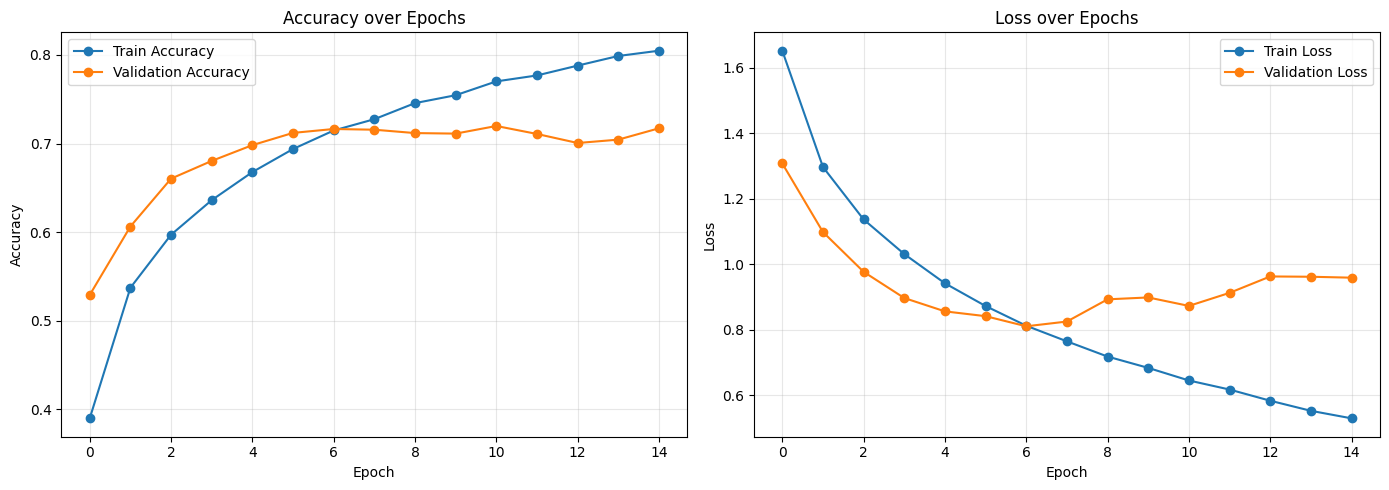

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Train Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='o')
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Evaluation: Accuracy, Precision, Recall, F1, Confusion Matrix

In [14]:
test_loss, test_acc = baseline_model.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

y_pred_probs = baseline_model.predict(x_test_norm, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

acc  = accuracy_score(y_test_flat, y_pred)
prec = precision_score(y_test_flat, y_pred, average='macro')
rec  = recall_score(y_test_flat, y_pred, average='macro')
f1   = f1_score(y_test_flat, y_pred, average='macro')

print(f"\nAccuracy : {acc:.4f}")
print(f"Precision (macro): {prec:.4f}")
print(f"Recall (macro)   : {rec:.4f}")
print(f"F1-score (macro) : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test_flat, y_pred, target_names=class_names))


Test Loss: 0.9989
Test Accuracy: 0.6972

Accuracy : 0.6972
Precision (macro): 0.7097
Recall (macro)   : 0.6972
F1-score (macro) : 0.6990

Classification Report:

              precision    recall  f1-score   support

    airplane       0.75      0.69      0.72      1000
  automobile       0.86      0.80      0.83      1000
        bird       0.69      0.50      0.58      1000
         cat       0.46      0.64      0.53      1000
        deer       0.66      0.64      0.65      1000
         dog       0.57      0.59      0.58      1000
        frog       0.82      0.69      0.75      1000
       horse       0.77      0.75      0.76      1000
        ship       0.74      0.86      0.79      1000
       truck       0.78      0.82      0.80      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000



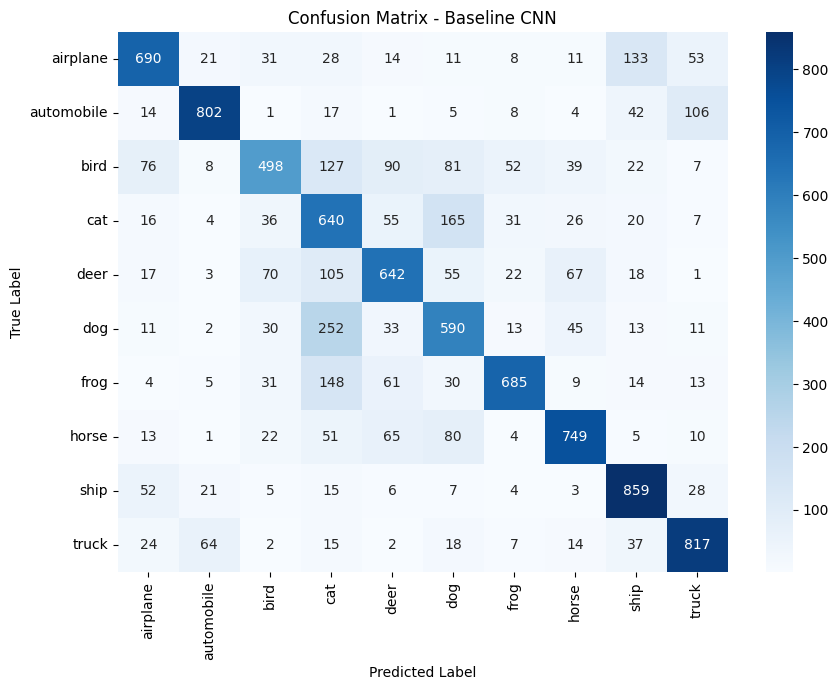

In [15]:
cm = confusion_matrix(y_test_flat, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Baseline CNN")
plt.tight_layout()
plt.show()


## 8. Visualizing Intermediate Feature Maps

We build a model that exposes the output of each convolutional layer so we can
see how the network progressively transforms an input image into abstract
feature representations.


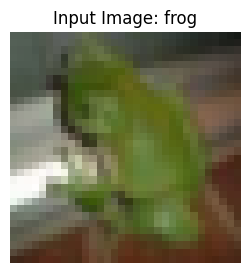

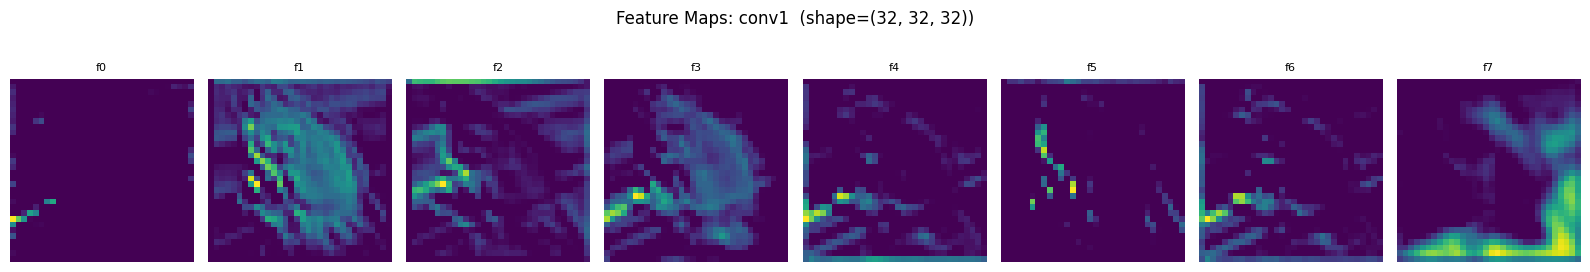

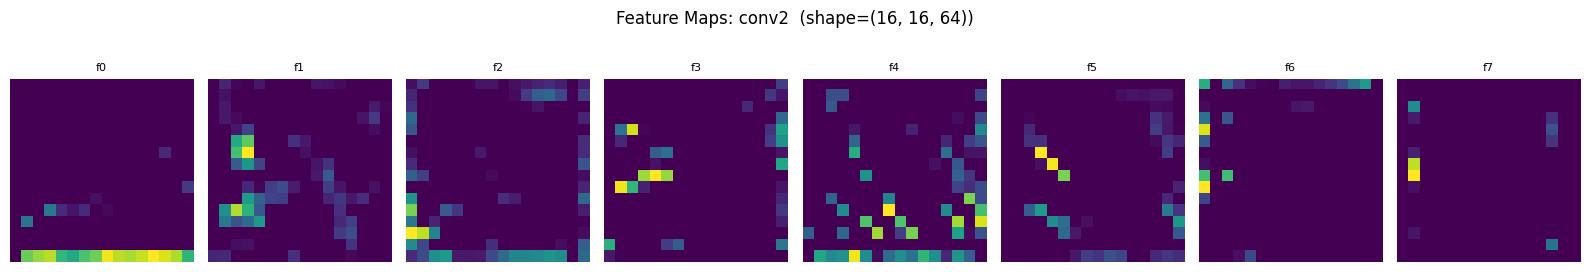

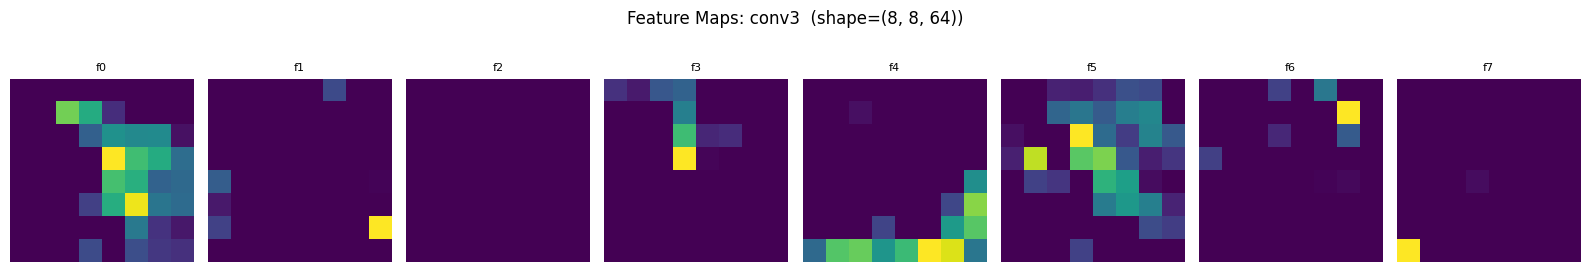

In [16]:
conv_layer_names = [layer.name for layer in baseline_model.layers if 'conv' in layer.name]
outputs = [baseline_model.get_layer(name).output for name in conv_layer_names]
feature_map_model = models.Model(inputs=baseline_model.inputs, outputs=outputs)

sample_img = x_test_norm[7:8]  # single image, keep batch dimension

plt.figure(figsize=(3, 3))
plt.imshow(x_test[7])
plt.title(f"Input Image: {class_names[y_test_flat[7]]}")
plt.axis('off')
plt.show()

feature_maps = feature_map_model.predict(sample_img, verbose=0)

for layer_name, fmap in zip(conv_layer_names, feature_maps):
    num_filters_to_show = min(8, fmap.shape[-1])
    fig, axes = plt.subplots(1, num_filters_to_show, figsize=(16, 3))
    for i in range(num_filters_to_show):
        axes[i].imshow(fmap[0, :, :, i], cmap='viridis')
        axes[i].axis('off')
        axes[i].set_title(f"f{i}", fontsize=8)
    plt.suptitle(f"Feature Maps: {layer_name}  (shape={fmap.shape[1:]})")
    plt.tight_layout()
    plt.show()


## 9. Hyperparameter Study: Kernel Size, Number of Filters, Stride/Padding

To keep runtime manageable, each configuration is trained for a small number
of epochs on a subset of the data. Increase `SUBSET_EPOCHS`, `SUBSET_SIZE`
for more reliable comparisons if compute allows.


In [17]:
SUBSET_SIZE = 15000
SUBSET_EPOCHS = 5

x_sub = x_train_norm[:SUBSET_SIZE]
y_sub = y_train_cat[:SUBSET_SIZE]

def build_configurable_cnn(kernel_size=(3, 3), num_filters=(32, 64), stride=1, padding='same'):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(num_filters[0], kernel_size, strides=stride, padding=padding, activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(num_filters[1], kernel_size, strides=stride, padding=padding, activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def evaluate_config(label, **kwargs):
    model = build_configurable_cnn(**kwargs)
    t0 = time.time()
    hist = model.fit(x_sub, y_sub, validation_split=0.1, epochs=SUBSET_EPOCHS,
                      batch_size=64, verbose=0)
    elapsed = time.time() - t0
    test_loss, test_acc = model.evaluate(x_test_norm, y_test_cat, verbose=0)
    print(f"{label:<35} | params={model.count_params():>9,} | "
          f"val_acc={hist.history['val_accuracy'][-1]:.4f} | "
          f"test_acc={test_acc:.4f} | time={elapsed:.1f}s")
    return {'label': label, 'params': model.count_params(),
            'val_acc': hist.history['val_accuracy'][-1], 'test_acc': test_acc, 'time': elapsed}

print("--- Kernel size comparison (filters fixed at 32,64) ---")
results_kernel = []
for k in [(3, 3), (5, 5), (7, 7)]:
    results_kernel.append(evaluate_config(f"kernel_size={k}", kernel_size=k))

print("\n--- Number of filters comparison (kernel fixed at 3x3) ---")
results_filters = []
for f in [(16, 32), (32, 64), (64, 128)]:
    results_filters.append(evaluate_config(f"filters={f}", num_filters=f))

print("\n--- Stride / padding comparison (kernel 3x3, filters 32,64) ---")
results_stride = []
for stride, pad in [(1, 'same'), (2, 'same'), (1, 'valid')]:
    results_stride.append(evaluate_config(f"stride={stride}, padding={pad}", stride=stride, padding=pad))


--- Kernel size comparison (filters fixed at 32,64) ---
kernel_size=(3, 3)                  | params=  282,250 | val_acc=0.5727 | test_acc=0.5787 | time=170.9s
kernel_size=(5, 5)                  | params=  316,554 | val_acc=0.5867 | test_acc=0.5943 | time=237.4s
kernel_size=(7, 7)                  | params=  368,010 | val_acc=0.5207 | test_acc=0.5294 | time=652.6s

--- Number of filters comparison (kernel fixed at 3x3) ---
filters=(16, 32)                    | params=  136,874 | val_acc=0.5533 | test_acc=0.5606 | time=81.0s
filters=(32, 64)                    | params=  282,250 | val_acc=0.5753 | test_acc=0.5892 | time=152.9s
filters=(64, 128)                   | params=  600,650 | val_acc=0.5893 | test_acc=0.6035 | time=338.1s

--- Stride / padding comparison (kernel 3x3, filters 32,64) ---
stride=1, padding=same              | params=  282,250 | val_acc=0.5620 | test_acc=0.5785 | time=170.8s
stride=2, padding=same              | params=   36,490 | val_acc=0.4787 | test_acc=0.4922 | 

/tmp/ipykernel_1456/1949116637.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
/tmp/ipykernel_1456/1949116637.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
/tmp/ipykernel_1456/1949116637.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)


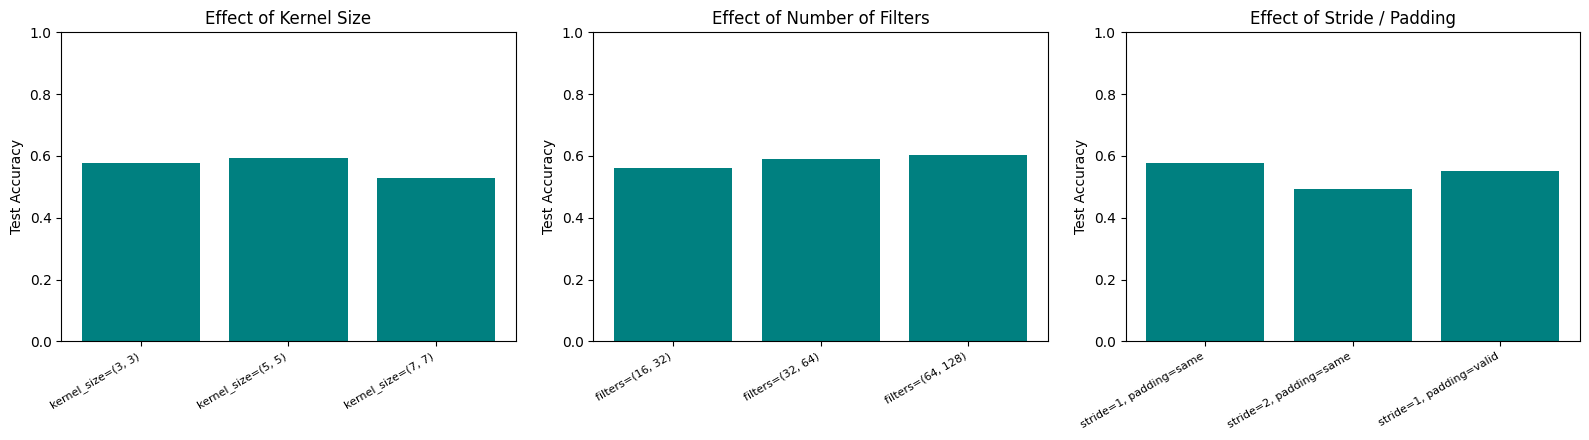

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

def plot_group(ax, results, title):
    labels = [r['label'] for r in results]
    accs = [r['test_acc'] for r in results]
    ax.bar(labels, accs, color='teal')
    ax.set_title(title)
    ax.set_ylabel("Test Accuracy")
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0, 1)

plot_group(axes[0], results_kernel, "Effect of Kernel Size")
plot_group(axes[1], results_filters, "Effect of Number of Filters")
plot_group(axes[2], results_stride, "Effect of Stride / Padding")

plt.tight_layout()
plt.show()


## 10. Pooling Strategy Comparison (Max vs Average vs None)

## 11. Optimizer & Batch Size Comparison

In [ ]:
print("--- Optimizer comparison ---")
optimizer_results = []
for opt_name in ['adam', 'sgd', 'rmsprop']:
    model = build_configurable_cnn()
    model.compile(optimizer=opt_name, loss='categorical_crossentropy', metrics=['accuracy'])
    hist = model.fit(x_sub, y_sub, validation_split=0.1, epochs=SUBSET_EPOCHS, batch_size=64, verbose=0)
    test_loss, test_acc = model.evaluate(x_test_norm, y_test_cat, verbose=0)
    optimizer_results.append({'optimizer': opt_name, 'test_acc': test_acc})
    print(f"optimizer={opt_name:<10} | test_acc={test_acc:.4f}")

print("\n--- Batch size comparison (optimizer=adam) ---")
batch_results = []
for bs in [32, 64, 128]:
    model = build_configurable_cnn()
    hist = model.fit(x_sub, y_sub, validation_split=0.1, epochs=SUBSET_EPOCHS, batch_size=bs, verbose=0)
    test_loss, test_acc = model.evaluate(x_test_norm, y_test_cat, verbose=0)
    batch_results.append({'batch_size': bs, 'test_acc': test_acc})
    print(f"batch_size={bs:<5} | test_acc={test_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar([r['optimizer'] for r in optimizer_results], [r['test_acc'] for r in optimizer_results], color='mediumseagreen')
axes[0].set_title("Effect of Optimizer")
axes[0].set_ylabel("Test Accuracy")

axes[1].bar([str(r['batch_size']) for r in batch_results], [r['test_acc'] for r in batch_results], color='crimson')
axes[1].set_title("Effect of Batch Size")
axes[1].set_ylabel("Test Accuracy")
plt.tight_layout()
plt.show()


## 12. Conclusion

Fill in observations after running the notebook, e.g.:

- **Kernel size:** Larger kernels capture broader spatial context per layer but increase
  parameter count and computation; 3x3 kernels stacked in depth are typically the most
  parameter-efficient choice (as in VGG-style networks).
- **Number of filters:** More filters increase model capacity and can improve accuracy,
  but raise the risk of overfitting and training time.
- **Stride/padding:** Larger strides downsample faster (fewer parameters downstream, less
  fine detail retained); `'valid'` padding shrinks spatial dimensions each layer while
  `'same'` preserves them.
- **Pooling:** Max pooling tends to retain the strongest activations (edges, salient
  features), while average pooling smooths the feature map; removing pooling entirely
  increases the parameter count of the flatten/dense stage substantially.
- **Optimizer:** Adam generally converges faster than plain SGD on this task within a
  small number of epochs; RMSprop often performs comparably to Adam.
- **Batch size:** Smaller batch sizes can generalize slightly better but train slower per
  epoch (more updates); larger batch sizes train faster per epoch but may need a higher
  learning rate to match performance.
- **Feature maps:** Early convolutional layers respond to low-level features like edges
  and color blobs, while deeper layers encode more abstract, class-discriminative patterns.
